 **E-Commerce User Behavior Analysis (EDA → Time Series → Preprocessing → Modelling)**

In [ ]:
import sys
!{sys.executable} -m pip install imbalanced-learn xgboost catboost scipy scikit-learn nbformat shap
import sys
!{sys.executable} -m pip install --upgrade nbformat ipython ipykernel plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
  Using cached ipython-9.13.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached ipykernel-7.2.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached ipython_pygments_lexers-1.1.1-py3-none-any.whl.metadata (1.1 kB)
  Using cached jedi-0.20.0-py2.py3-none-any.whl.metadata (23 kB)
  Using cached stack_data-0.6.3-py3-none-any.whl.metadata (18 kB)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached jupyter_client-8.8.0-py3-none-any.whl.metadata (8.4 kB)
  Using cached executing-2.2.1-py2.py3-none-any.whl.metadata (8.9 kB)
  Using cached asttokens-3.0.1-py3-none-any.whl.metadata (4.9 kB)
Using cached ipython-9.13.0-py3-none-any.whl (627 kB)
Using cached ipykernel-7.2.0-py3-none-any.whl (118 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached comm-0.2.3-py3-none-any.whl (7.3 kB)
U

In [ ]:

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_curve, precision_recall_curve)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import brier_score_loss

In [ ]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from scipy.stats import randint, uniform


SEED   = 42
COLORS = px.colors.qualitative.Plotly
print("All libraries imported successfully")

All libraries imported successfully


## 1. Load Data

In [ ]:

df = pd.read_csv("ecommerce_user_behavior_8000.csv")
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (8000, 14)
Columns: ['user_id', 'age', 'gender', 'device_type', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'discount_seen', 'ad_clicked', 'returning_user', 'avg_session_time', 'bounce_rate', 'purchase']


,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
0,1.0,56.0,Female,Desktop,12.90,8.0,13.0,1.0,1.0,NaN,0.0,6.97,28.18,1.0
1,2.0,46.0,Male,Mobile,15.63,9.0,4.0,6.0,1.0,1.0,1.0,19.17,86.73,1.0
2,3.0,32.0,Female,NaN,11.64,12.0,11.0,0.0,0.0,0.0,1.0,8.87,83.09,1.0
3,4.0,25.0,Female,Mobile,22.71,5.0,10.0,1.0,0.0,0.0,1.0,NaN,79.03,1.0
4,5.0,38.0,Female,Mobile,26.35,9.0,12.0,4.0,1.0,0.0,0.0,18.15,55.35,1.0


In [ ]:
df.tail(10)

,user_id,age,gender,device_type,time_on_site,pages_viewed,previous_purchases,cart_items,discount_seen,ad_clicked,returning_user,avg_session_time,bounce_rate,purchase
7990,7991.0,47.0,Female,Desktop,17.16,11.0,9.0,6.0,0.0,1.0,0.0,15.52,57.23,1.0
7991,7992.0,40.0,Female,Desktop,12.96,1.0,11.0,7.0,1.0,0.0,1.0,18.61,3.16,1.0
7992,7993.0,36.0,Female,Mobile,5.90,5.0,7.0,0.0,1.0,1.0,1.0,4.69,99.40,1.0
7993,7994.0,29.0,Male,Mobile,3.15,18.0,3.0,9.0,1.0,0.0,1.0,2.59,11.49,1.0
7994,7995.0,32.0,Female,Desktop,7.85,1.0,6.0,5.0,1.0,1.0,0.0,10.80,18.08,1.0
7995,7996.0,48.0,Female,Tablet,2.67,10.0,6.0,0.0,1.0,0.0,1.0,3.01,82.44,1.0
7996,7997.0,54.0,Male,Mobile,18.94,13.0,11.0,4.0,1.0,1.0,1.0,27.48,10.06,1.0
7997,7998.0,54.0,Female,Desktop,24.08,8.0,13.0,1.0,0.0,0.0,1.0,27.57,21.34,1.0
7998,7999.0,32.0,Female,Mobile,10.85,13.0,12.0,8.0,1.0,1.0,0.0,5.78,2.03,1.0
7999,8000.0,46.0,Female,Mobile,12.23,2.0,9.0,2.0,0.0,1.0,1.0,8.28,15.67,1.0


In [ ]:
# Data types

df.dtypes

,0
user_id,float64
age,float64
gender,object
device_type,object
time_on_site,float64
pages_viewed,float64
previous_purchases,float64
cart_items,float64
discount_seen,float64
ad_clicked,float64


In [ ]:
# Descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,7840.0,4003.135077,2307.898984,1.00,2011.7500,3998.00,6001.2500,8000.00
age,7840.0,38.595791,12.033928,18.00,28.0000,39.00,49.0000,59.00
time_on_site,7840.0,15.714673,8.362764,1.00,8.5200,15.74,22.8800,30.00
pages_viewed,7840.0,9.970026,5.425485,1.00,5.0000,10.00,15.0000,19.00
previous_purchases,7840.0,6.964158,4.281117,0.00,3.0000,7.00,11.0000,14.00
cart_items,7840.0,4.530230,2.865814,0.00,2.0000,5.00,7.0000,9.00
discount_seen,7840.0,0.502551,0.500025,0.00,0.0000,1.00,1.0000,1.00
ad_clicked,7840.0,0.502296,0.500027,0.00,0.0000,1.00,1.0000,1.00
returning_user,7840.0,0.509439,0.499943,0.00,0.0000,1.00,1.0000,1.00
avg_session_time,7840.0,15.794999,9.864556,0.57,7.7500,14.30,22.3925,44.75


In [ ]:
# Missing values

missing = df.isnull().sum()
pct     = (missing / len(df) * 100).round(2)
pd.DataFrame({"Missing": missing, "Pct (%)": pct}).query("Missing > 0")

,Missing,Pct (%)
user_id,160,2.0
age,160,2.0
gender,160,2.0
device_type,160,2.0
time_on_site,160,2.0
pages_viewed,160,2.0
previous_purchases,160,2.0
cart_items,160,2.0
discount_seen,160,2.0
ad_clicked,160,2.0


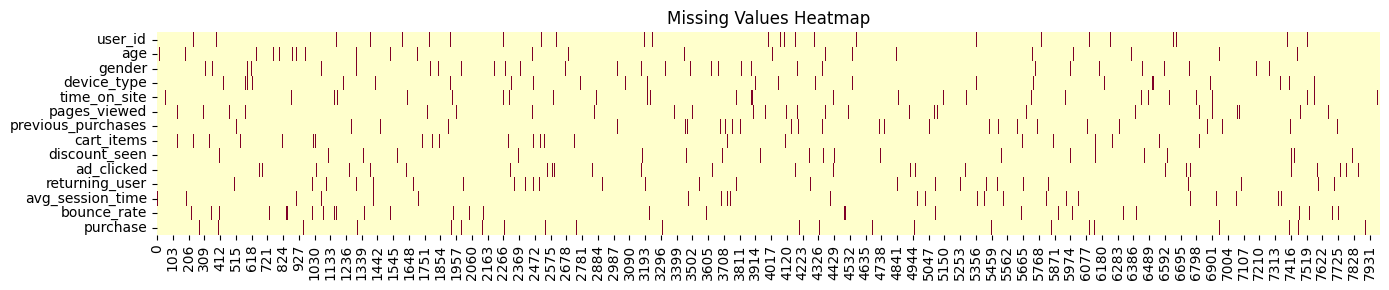

In [ ]:
# Missing-value heatmap

plt.figure(figsize=(14, 3))
sns.heatmap(df.isnull().T, cbar=False, cmap="YlOrRd", yticklabels=df.columns)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

## 2. Time Series Analysis

In [ ]:

date_range = pd.date_range('2024-01-01', '2024-12-31', freq='h')
rng = np.random.default_rng(SEED)
n = len(df)
timestamps = pd.to_datetime(rng.choice(date_range, size=n, replace=True)).sort_values()

df_ts = df.copy()
df_ts['timestamp']   = timestamps.values
df_ts['date']        = df_ts['timestamp'].dt.date
df_ts['hour']        = df_ts['timestamp'].dt.hour
df_ts['day_of_week'] = df_ts['timestamp'].dt.day_name()
df_ts['month']       = df_ts['timestamp'].dt.month
df_ts['week']        = df_ts['timestamp'].dt.isocalendar().week.astype(int)
df_ts['is_weekend']  = df_ts['timestamp'].dt.dayofweek >= 5
df_ts['quarter']     = df_ts['timestamp'].dt.quarter

print('Timestamp range:', df_ts['timestamp'].min(), '→', df_ts['timestamp'].max())
df_ts[['timestamp','hour','day_of_week','month','is_weekend']].head()

Timestamp range: 2024-01-01 00:00:00 → 2024-12-30 22:00:00


,timestamp,hour,day_of_week,month,is_weekend
0,2024-01-01 00:00:00,0,Monday,1,False
1,2024-01-01 04:00:00,4,Monday,1,False
2,2024-01-01 04:00:00,4,Monday,1,False
3,2024-01-01 05:00:00,5,Monday,1,False
4,2024-01-01 07:00:00,7,Monday,1,False


In [ ]:
# Daily sessions & purchases with 7-day moving average

daily = df_ts.groupby('date').agg(
    sessions=('purchase', 'count'),
    purchases=('purchase', 'sum')
).reset_index()
daily['date'] = pd.to_datetime(daily['date'])
daily['purchase_rate'] = daily['purchases'] / daily['sessions']
daily['sessions_7d']   = daily['sessions'].rolling(7, center=True).mean()
daily['purchases_7d']  = daily['purchases'].rolling(7, center=True).mean()

fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=['Daily Sessions (raw + 7-day MA)', 'Daily Purchases (raw + 7-day MA)'],vertical_spacing=0.08)

fig.add_trace(go.Scatter(x=daily['date'], y=daily['sessions'],
                         mode='lines', line=dict(color='rgba(31,119,180,0.3)', width=1), name='Sessions (raw)'), row=1, col=1)
fig.add_trace(go.Scatter(x=daily['date'], y=daily['sessions_7d'],
                         mode='lines', line=dict(color='#1f77b4', width=2.5), name='Sessions 7d MA'), row=1, col=1)
fig.add_trace(go.Scatter(x=daily['date'], y=daily['purchases'],
                         mode='lines', line=dict(color='rgba(44,160,44,0.3)', width=1), name='Purchases (raw)'), row=2, col=1)
fig.add_trace(go.Scatter(x=daily['date'], y=daily['purchases_7d'],
                         mode='lines', line=dict(color='#2ca02c', width=2.5), name='Purchases 7d MA'), row=2, col=1)
fig.update_layout(title='Daily Traffic & Purchase Volume — Jan to Dec 2024', height=550, hovermode='x unified')

fig.show()

In [ ]:
# Monthly seasonality

monthly = df_ts.groupby('month').agg(
    sessions=('purchase', 'count'), purchases=('purchase', 'sum'),
    avg_time_on_site=('time_on_site', 'mean'), avg_cart=('cart_items', 'mean')
).reset_index()
monthly['purchase_rate'] = monthly['purchases'] / monthly['sessions']
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

fig = make_subplots(rows=2, cols=2,
                    subplot_titles=['Monthly Sessions','Purchase Rate by Month','Avg Time on Site','Avg Cart Items'])
fig.add_trace(go.Bar(x=monthly['month_name'], y=monthly['sessions'], marker_color=COLORS[0], name='Sessions'), row=1, col=1)
fig.add_trace(go.Scatter(x=monthly['month_name'], y=monthly['purchase_rate'], mode='lines+markers',
                         line=dict(color=COLORS[1], width=2.5), marker_size=8, name='Purchase Rate'), row=1, col=2)
fig.add_trace(go.Scatter(x=monthly['month_name'], y=monthly['avg_time_on_site'], mode='lines+markers',
                         line=dict(color=COLORS[2], width=2.5), marker_size=8, name='Avg Time'), row=2, col=1)
fig.add_trace(go.Bar(x=monthly['month_name'], y=monthly['avg_cart'], marker_color=COLORS[3], name='Avg Cart'), row=2, col=2)
fig.update_layout(title='Monthly Seasonality Analysis', height=580, showlegend=False)
fig.show()

In [ ]:
# Day of week & hour of day patterns

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df_ts.groupby('day_of_week').agg(sessions=('purchase','count'), purchases=('purchase','sum')).reindex(dow_order).reset_index()
dow['purchase_rate'] = dow['purchases'] / dow['sessions']
hourly = df_ts.groupby('hour').agg(sessions=('purchase','count'), purchases=('purchase','sum')).reset_index()
hourly['purchase_rate'] = hourly['purchases'] / hourly['sessions']

fig = make_subplots(rows=1, cols=2, subplot_titles=['Sessions by Day of Week','Sessions by Hour of Day'])
fig.add_trace(go.Bar(x=dow['day_of_week'], y=dow['sessions'],
                     marker_color=['#e74c3c' if d in ['Saturday','Sunday'] else '#3498db' for d in dow['day_of_week']],
                     text=dow['sessions'], textposition='outside', name='Sessions'), row=1, col=1)
fig.add_trace(go.Bar(x=hourly['hour'], y=hourly['sessions'], marker_color=COLORS[1],
                     text=hourly['sessions'], textposition='outside', name='Hourly'), row=1, col=2)
fig.update_layout(title='When do users shop? Day & Hour Patterns', height=420, showlegend=False)
fig.show()

In [ ]:
# Weekend vs Weekday behaviour

wk = df_ts.groupby('is_weekend')[['time_on_site','pages_viewed','cart_items','avg_session_time','bounce_rate']].mean().reset_index()
wk['is_weekend'] = wk['is_weekend'].map({True:'Weekend', False:'Weekday'})
wk_melt = wk.melt(id_vars='is_weekend', var_name='Metric', value_name='Value')
fig = px.bar(wk_melt, x='Metric', y='Value', color='is_weekend', barmode='group',
             color_discrete_map={'Weekday':'#3498db','Weekend':'#e74c3c'},
             title='Weekend vs Weekday: Average User Behaviour Metrics', text_auto='.2f')
fig.update_traces(textposition='outside')
fig.update_layout(height=430, xaxis_tickangle=-20)
fig.show()

In [ ]:
# Rolling 14-day engagement trends

daily_full = df_ts.groupby('date').agg(
    avg_time_on_site=('time_on_site','mean'), avg_pages=('pages_viewed','mean'),
    avg_cart=('cart_items','mean'), avg_bounce=('bounce_rate','mean')
).reset_index()
daily_full['date'] = pd.to_datetime(daily_full['date'])
for col in ['avg_time_on_site','avg_pages','avg_cart','avg_bounce']:
    daily_full[col+'_14d'] = daily_full[col].rolling(14, center=True).mean()

fig = make_subplots(rows=2, cols=2, shared_xaxes=True,
                    subplot_titles=['Avg Time on Site (14d MA)','Avg Pages Viewed (14d MA)',
                                    'Avg Cart Items (14d MA)','Avg Bounce Rate (14d MA)'],
                    vertical_spacing=0.1)
pairs = [('avg_time_on_site','#1f77b4',1,1),('avg_pages','#ff7f0e',1,2),
         ('avg_cart','#2ca02c',2,1),('avg_bounce','#d62728',2,2)]
for base, color, r, c in pairs:
    fig.add_trace(go.Scatter(x=daily_full['date'], y=daily_full[base], mode='lines',
                             line=dict(color=color, width=1), opacity=0.3, showlegend=False), row=r, col=c)
    fig.add_trace(go.Scatter(x=daily_full['date'], y=daily_full[base+'_14d'], mode='lines',
                             line=dict(color=color, width=2.5), name=base, showlegend=False), row=r, col=c)
fig.update_layout(title='Rolling 14-Day Engagement Trends', height=560)
fig.show()

In [ ]:
# Session heatmap: Hour × Day

pivot = df_ts.groupby(['day_of_week','hour']).size().reset_index(name='count')
pivot_mat = pivot.pivot(index='day_of_week', columns='hour', values='count').reindex(dow_order)
fig = go.Figure(go.Heatmap(z=pivot_mat.values, x=pivot_mat.columns, y=pivot_mat.index,
                           colorscale='Viridis', colorbar=dict(title='Sessions')))
fig.update_layout(title='Session Heatmap: Hour of Day × Day of Week',
                  xaxis_title='Hour of Day', yaxis_title='Day of Week', height=420)
fig.show()

In [ ]:
# Cohort: New vs Returning users by Quarter

cohort = df_ts.groupby(['quarter','returning_user']).agg(
    sessions=('purchase','count'), purchases=('purchase','sum'), avg_cart=('cart_items','mean')
).reset_index()
cohort['purchase_rate'] = cohort['purchases'] / cohort['sessions']
cohort['user_type'] = cohort['returning_user'].map({1.0:'Returning', 0.0:'New'})
cohort['Q'] = 'Q' + cohort['quarter'].astype(str)

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Purchase Rate by Quarter & User Type','Avg Cart by Quarter & User Type'])
for label, color in [('Returning','#2ecc71'),('New','#e74c3c')]:
    sub = cohort[cohort['user_type']==label]
    fig.add_trace(go.Bar(x=sub['Q'], y=sub['purchase_rate'], name=label, marker_color=color, legendgroup=label,
                         text=(sub['purchase_rate']*100).round(1).astype(str)+'%', textposition='outside'), row=1, col=1)
    fig.add_trace(go.Bar(x=sub['Q'], y=sub['avg_cart'], name=label, marker_color=color, legendgroup=label,
                         showlegend=False, text=sub['avg_cart'].round(2), textposition='outside'), row=1, col=2)
fig.update_layout(title='Cohort: New vs Returning Users by Quarter', height=450, barmode='group')
fig.show()

## 3. Exploratory Data Analysis (EDA)

In [ ]:
# Target variable distribution

vc = df["purchase"].value_counts().reset_index()
vc.columns = ["purchase", "count"]
vc["label"] = vc["purchase"].map({1.0: "Purchase (1)", 0.0: "No Purchase (0)"})

fig = make_subplots(rows=1, cols=2, subplot_titles=["Count", "Proportion"],
                    specs=[[{"type": "bar"}, {"type": "pie"}]])
fig.add_trace(go.Bar(x=vc["label"], y=vc["count"], marker_color=["#2ecc71","#e74c3c"],
                     text=vc["count"], textposition="outside"), row=1, col=1)
fig.add_trace(go.Pie(labels=vc["label"], values=vc["count"], marker_colors=["#2ecc71","#e74c3c"],
                     hole=0.35, textinfo="percent+label"), row=1, col=2)
fig.update_layout(title="Target Distribution", height=420, showlegend=False)
fig.show()

In [ ]:
# Numerical feature distributions

num_cols = ["age","time_on_site","pages_viewed","previous_purchases","cart_items","avg_session_time","bounce_rate"]
fig = make_subplots(rows=2, cols=4, subplot_titles=num_cols, vertical_spacing=0.12)
for i, col in enumerate(num_cols):
    r, c = divmod(i, 4)
    fig.add_trace(go.Histogram(x=df[col].dropna(), nbinsx=30,
                               marker_color=COLORS[i], name=col, showlegend=False), row=r+1, col=c+1)
fig.update_layout(title="Numerical Feature Distributions", height=550, bargap=0.05)
fig.show()


In [ ]:
# Categorical feature distributions

cat_cols = ["gender","device_type"]
bin_cols = ["discount_seen","ad_clicked","returning_user"]
bin_labels = {0.0:"No / New", 1.0:"Yes / Returning"}

fig = make_subplots(rows=1, cols=5, subplot_titles=cat_cols + bin_cols)
for i, col in enumerate(cat_cols + bin_cols):
    data = df[col].copy()
    if col in bin_cols:
        data = data.map(bin_labels)
    vc2 = data.value_counts().reset_index(); vc2.columns = ["val","cnt"]
    fig.add_trace(go.Bar(x=vc2["val"].astype(str), y=vc2["cnt"],
                         marker_color=COLORS[i % len(COLORS)],
                         text=vc2["cnt"], textposition="outside", showlegend=False), row=1, col=i+1)
fig.update_layout(title="Categorical Feature Distributions", height=420)
fig.show()

In [ ]:
# Correlation matrix

heat_cols = num_cols + ["discount_seen","ad_clicked","returning_user","purchase"]
corr = df[heat_cols].corr().round(2)
fig = go.Figure(go.Heatmap(z=corr.values, x=corr.columns, y=corr.index,
                           colorscale="RdBu", zmid=0, text=corr.values,
                           texttemplate="%{text}", textfont_size=10, colorbar=dict(title="r")))
fig.update_layout(title="Correlation Matrix", height=580, width=700, xaxis_tickangle=-35)
fig.show()

In [ ]:
# Box plots by purchase status

df_plot = df.copy()
df_plot["purchase_label"] = df_plot["purchase"].map({1.0:"Purchase", 0.0:"No Purchase"})
fig = make_subplots(rows=2, cols=4, subplot_titles=num_cols, vertical_spacing=0.14)
for i, col in enumerate(num_cols):
    r, c = divmod(i, 4)
    for label, color in [("Purchase","#2ecc71"),("No Purchase","#e74c3c")]:
        vals = df_plot.loc[df_plot["purchase_label"]==label, col].dropna()
        fig.add_trace(go.Box(y=vals, name=label, marker_color=color,
                             legendgroup=label, showlegend=(i==0)), row=r+1, col=c+1)
fig.update_layout(title="Feature Distribution by Purchase Status", height=600, boxmode="group")
fig.show()

In [ ]:
# Purchase rate by categorical features

fig = make_subplots(rows=1, cols=5, subplot_titles=cat_cols + bin_cols)
for i, col in enumerate(cat_cols + bin_cols):
    rate = df.groupby(col)["purchase"].mean().reset_index(); rate.columns = ["val","rate"]
    fig.add_trace(go.Bar(x=rate["val"].astype(str), y=rate["rate"],
                         marker_color=COLORS[i % len(COLORS)],
                         text=(rate["rate"]*100).round(1).astype(str)+"%",
                         textposition="outside", showlegend=False), row=1, col=i+1)
fig.update_yaxes(range=[0,1.15])
fig.update_layout(title="Purchase Rate by Categorical Features", height=420)
fig.show()

In [ ]:
# Scatter matrix

subset = df[["age","time_on_site","pages_viewed","cart_items","bounce_rate","purchase"]].dropna()
subset["purchase"] = subset["purchase"].astype(int).astype(str)
fig = px.scatter_matrix(subset,
    dimensions=["age","time_on_site","pages_viewed","cart_items","bounce_rate"],
    color="purchase", color_discrete_map={"1":"#2ecc71","0":"#e74c3c"},
    labels={"purchase":"Purchase"}, title="Scatter Matrix — Key Numeric Features", opacity=0.4)
fig.update_traces(diagonal_visible=False, marker_size=3)
fig.update_layout(height=700)
fig.show()

## 4. Preprocessing & Feature Engineering

In [ ]:

print(f"Raw shape: {df.shape}")
df = df.drop(columns=[c for c in ["user_id"] if c in df.columns]).copy()
df = df.dropna(subset=["purchase"])
print(f"Shape after dropping missing target: {df.shape}")

Raw shape: (8000, 14)
Shape after dropping missing target: (7840, 13)


In [ ]:

num_feats = ["age","time_on_site","pages_viewed","previous_purchases","cart_items","avg_session_time","bounce_rate"]
bin_feats = ["discount_seen","ad_clicked","returning_user"]
cat_feats = ["gender","device_type"]

for col in num_feats + bin_feats:
    df[col] = df[col].fillna(df[col].median())
for col in cat_feats:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values after imputation: {df.isnull().sum().sum()}")

Missing values after imputation: 0


In [ ]:

le_gender = LabelEncoder()
le_device  = LabelEncoder()
df["gender_enc"]      = le_gender.fit_transform(df["gender"])
df["device_type_enc"] = le_device.fit_transform(df["device_type"])
print("gender mapping:     ", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))
print("device_type mapping:", dict(zip(le_device.classes_,  le_device.transform(le_device.classes_))))

gender mapping:      {'Female': np.int64(0), 'Male': np.int64(1)}
device_type mapping: {'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Tablet': np.int64(2)}


In [ ]:
# Feature engineering

df["engagement_score"]   = (df["pages_viewed"] * df["time_on_site"]) / (df["avg_session_time"] + 1e-5)
df["cart_to_page_ratio"] = df["cart_items"] / (df["pages_viewed"] + 1e-5)
df["loyal_buyer"]        = ((df["previous_purchases"] > 3) & (df["returning_user"] == 1)).astype(int)
df["high_engagement"]    = (df["engagement_score"] > df["engagement_score"].median()).astype(int)

print("Engineered: engagement_score | cart_to_page_ratio | loyal_buyer | high_engagement")
df[["engagement_score","cart_to_page_ratio","loyal_buyer","high_engagement"]].describe()

Engineered: engagement_score | cart_to_page_ratio | loyal_buyer | high_engagement


,engagement_score,cart_to_page_ratio,loyal_buyer,high_engagement
count,7840.000000,7840.000000,7840.000000,7840.000000
mean,11.064459,0.837823,0.382143,0.500000
std,8.019296,1.284193,0.485942,0.500032
min,0.116084,0.000000,0.000000,0.000000
25%,5.340645,0.210526,0.000000,0.000000
50%,9.919785,0.454545,0.000000,0.500000
75%,14.850911,0.874999,1.000000,1.000000
max,215.762591,8.999910,1.000000,1.000000


In [ ]:
# Outlier capping (IQR)

cap_cols = ["time_on_site","pages_viewed","cart_items","avg_session_time","engagement_score","cart_to_page_ratio"]
cap_summary = []
for col in cap_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    cap_summary.append({"Feature": col, "Outliers Capped": n_out})

fig = px.bar(pd.DataFrame(cap_summary), x="Feature", y="Outliers Capped",
             text="Outliers Capped", color="Outliers Capped", color_continuous_scale="Oranges",
             title="Outliers Capped per Feature (IQR Method)")
fig.update_traces(textposition="outside")
fig.update_layout(coloraxis_showscale=False, height=380)
fig.show()

In [ ]:

FEATURES = (num_feats + bin_feats +
            ["gender_enc","device_type_enc","engagement_score","cart_to_page_ratio","loyal_buyer","high_engagement"])
TARGET = "purchase"

df_model = df[FEATURES + [TARGET]].copy()
df_model[TARGET] = df_model[TARGET].astype(int)

print(f"Final modelling dataframe: {df_model.shape}")

print(f"Features ({len(FEATURES)}): {FEATURES}")
df_model.head(3)

Final modelling dataframe: (7840, 17)
Features (16): ['age', 'time_on_site', 'pages_viewed', 'previous_purchases', 'cart_items', 'avg_session_time', 'bounce_rate', 'discount_seen', 'ad_clicked', 'returning_user', 'gender_enc', 'device_type_enc', 'engagement_score', 'cart_to_page_ratio', 'loyal_buyer', 'high_engagement']


,age,time_on_site,pages_viewed,previous_purchases,cart_items,avg_session_time,bounce_rate,discount_seen,ad_clicked,returning_user,gender_enc,device_type_enc,engagement_score,cart_to_page_ratio,loyal_buyer,high_engagement,purchase
0,56.0,12.90,8.0,13.0,1.0,6.97,28.18,1.0,1.0,0.0,0,0,14.806292,0.125000,0,1,1
1,46.0,15.63,9.0,4.0,6.0,19.17,86.73,1.0,1.0,1.0,1,1,7.338024,0.666666,1,0,1
2,32.0,11.64,12.0,11.0,0.0,8.87,83.09,0.0,0.0,1.0,0,1,15.747446,0.000000,1,1,1


In [ ]:
# Correlation matrix — clean feature set

corr = df_model[FEATURES + [TARGET]].corr().round(2)

fig = go.Figure(go.Heatmap(z=corr.values, x=corr.columns, y=corr.index,
                           colorscale="RdBu", zmid=0, text=corr.values,
                           texttemplate="%{text}", textfont_size=9, colorbar=dict(title="r")))

fig.update_layout(title="Correlation Matrix — Clean Feature Set", height=650, width=800, xaxis_tickangle=-40)
fig.show()

In [ ]:
# Feature correlation with target

target_corr = df_model[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
colors_bar = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr.values]
fig = go.Figure(go.Bar(x=target_corr.values, y=target_corr.index, orientation="h",
                       marker_color=colors_bar, text=target_corr.round(3).values, textposition="outside"))
fig.update_layout(title="Feature Correlation with Target (purchase)", xaxis_title="Pearson r", height=500)
fig.show()

## 5. Model Training & Evaluation

> Models: Decision Tree · Random Forest · Gradient Boosting · XGBoost · **CatBoost** · KNN · Naive Bayes  
> Strategy: SMOTE oversampling inside each CV fold to prevent data leakage.

In [ ]:

FEATURES = (num_feats + bin_feats +
            ['gender_enc', 'device_type_enc',
             'engagement_score', 'cart_to_page_ratio', 'loyal_buyer', 'high_engagement'])
TARGET = 'purchase'

X = df[FEATURES]
y = df[TARGET].astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    stratify=y, random_state=SEED)

# Preprocessing pipeline (numeric scaling + one‑hot encoding)
def get_preprocessor(X):
    num_cols = X.select_dtypes(include=['int64','float64']).columns
    cat_cols = X.select_dtypes(include=['object']).columns
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipeline, num_cols),
        ('cat', cat_pipeline, cat_cols)
    ])

preprocessor = get_preprocessor(X)


In [ ]:

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=6,
                                            min_samples_leaf=10,
                                            class_weight='balanced',
                                            random_state=SEED),
    'XGBoost': XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                             scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
                             eval_metric='logloss', random_state=SEED),
    'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.05, depth=3,
                                   auto_class_weights='Balanced',
                                   random_seed=SEED, verbose=False),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                            class_weight='balanced',
                                            random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05,
                                                    max_depth=3, subsample=0.8,
                                                    random_state=SEED),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB()
}

results = []
fitted_pipelines = {}
print("\n--- Training models with SMOTE ---")
for name, model in models.items():
    pipeline = ImbPipeline([
        ('prep', preprocessor),
        ('smote', SMOTE(random_state=SEED)),
        ('clf', model)
    ])
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    results.append({'Model': name, 'Test ROC‑AUC': auc, 'Test AP': ap})
    fitted_pipelines[name] = pipeline
    print(f"{name:20s} ROC‑AUC = {auc:.4f}, AP = {ap:.4f}")

results_df = pd.DataFrame(results).sort_values('Test ROC‑AUC', ascending=False)
best_model_name = results_df.iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
print(f"\nBest model: {best_model_name} (ROC‑AUC = {results_df.iloc[0]['Test ROC‑AUC']:.4f})")


--- Training models with SMOTE ---
Random Forest        ROC‑AUC = 0.9720, AP = 0.9999
XGBoost              ROC‑AUC = 0.9899, AP = 1.0000
CatBoost             ROC‑AUC = 0.9921, AP = 1.0000
Decision Tree        ROC‑AUC = 0.7486, AP = 0.9991
Gradient Boosting    ROC‑AUC = 0.9804, AP = 1.0000
KNN                  ROC‑AUC = 0.8728, AP = 0.9996
Naive Bayes          ROC‑AUC = 0.9914, AP = 1.0000

Best model: CatBoost (ROC‑AUC = 0.9921)


In [ ]:

print("\n--- Stratified K‑Fold Cross‑Validation (5 folds) ---")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(best_pipeline, X, y, cv=cv, scoring='roc_auc')
for i, s in enumerate(cv_scores, 1):
    print(f"Fold {i}: {s:.4f}")
print(f"Mean CV ROC‑AUC = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")


--- Stratified K‑Fold Cross‑Validation (5 folds) ---
Fold 1: 0.9984
Fold 2: 0.9990
Fold 3: 0.9974
Fold 4: 0.9800
Fold 5: 0.9902
Mean CV ROC‑AUC = 0.9930 (±0.0073)


In [ ]:

def compare_rebalancing(model_name, preprocessor, X_train, X_test, y_train, y_test):
    model_configs = {
        'Random Forest': lambda: RandomForestClassifier(n_estimators=100, max_depth=6,
                                                        min_samples_leaf=10,
                                                        random_state=SEED),
        'XGBoost': lambda: XGBClassifier(n_estimators=100, learning_rate=0.05,
                                         max_depth=3, eval_metric='logloss',
                                         random_state=SEED),
        'CatBoost': lambda: CatBoostClassifier(iterations=100, learning_rate=0.05,
                                               depth=3, random_seed=SEED, verbose=False),
        'Decision Tree': lambda: DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                        random_state=SEED),
        'Gradient Boosting': lambda: GradientBoostingClassifier(n_estimators=100,
                                                                learning_rate=0.05,
                                                                max_depth=3, subsample=0.8,
                                                                random_state=SEED),
        'KNN': lambda: KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes': lambda: GaussianNB(),
    }
    base_model = model_configs[model_name]()

    # Weighted version (if supported)
    if model_name == 'XGBoost':
        clf_weighted = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3,
                                     scale_pos_weight=(len(y_train)-y_train.sum())/y_train.sum(),
                                     eval_metric='logloss', random_state=SEED)
    elif model_name == 'CatBoost':
        clf_weighted = CatBoostClassifier(iterations=100, learning_rate=0.05, depth=3,
                                          auto_class_weights='Balanced',
                                          random_seed=SEED, verbose=False)
    elif model_name in ['Random Forest', 'Decision Tree']:
        clf_weighted = model_configs[model_name]()
        clf_weighted.set_params(class_weight='balanced')
    else:
        clf_weighted = None

    # SMOTE pipeline
    pipe_smote = ImbPipeline([('prep', preprocessor), ('smote', SMOTE(random_state=SEED)), ('clf', base_model)])
    pipe_smote.fit(X_train, y_train)
    y_proba_smote = pipe_smote.predict_proba(X_test)[:, 1]
    auc_smote = roc_auc_score(y_test, y_proba_smote)

    # Baseline (no rebalancing)
    pipe_baseline = Pipeline([('prep', preprocessor), ('clf', base_model)])
    pipe_baseline.fit(X_train, y_train)
    y_proba_baseline = pipe_baseline.predict_proba(X_test)[:, 1]
    auc_baseline = roc_auc_score(y_test, y_proba_baseline)

    comp = {'Method': ['SMOTE-resampled', 'Original (baseline)'],
            'Test ROC‑AUC': [auc_smote, auc_baseline]}
    if clf_weighted is not None:
        pipe_weighted = Pipeline([('prep', preprocessor), ('clf', clf_weighted)])
        pipe_weighted.fit(X_train, y_train)
        y_proba_weighted = pipe_weighted.predict_proba(X_test)[:, 1]
        auc_weighted = roc_auc_score(y_test, y_proba_weighted)
        comp['Method'].insert(0, 'Original (class weights)')
        comp['Test ROC‑AUC'].insert(0, auc_weighted)
    return pd.DataFrame(comp)

print("\n--- Rebalancing Strategies Comparison ---")
comp_df = compare_rebalancing(best_model_name, preprocessor, X_train, X_test, y_train, y_test)
print(comp_df.to_string(index=False))



--- Rebalancing Strategies Comparison ---
                  Method  Test ROC‑AUC
Original (class weights)      0.995102
         SMOTE-resampled      0.992121
     Original (baseline)      0.994144



--- SHAP Feature Importance ---


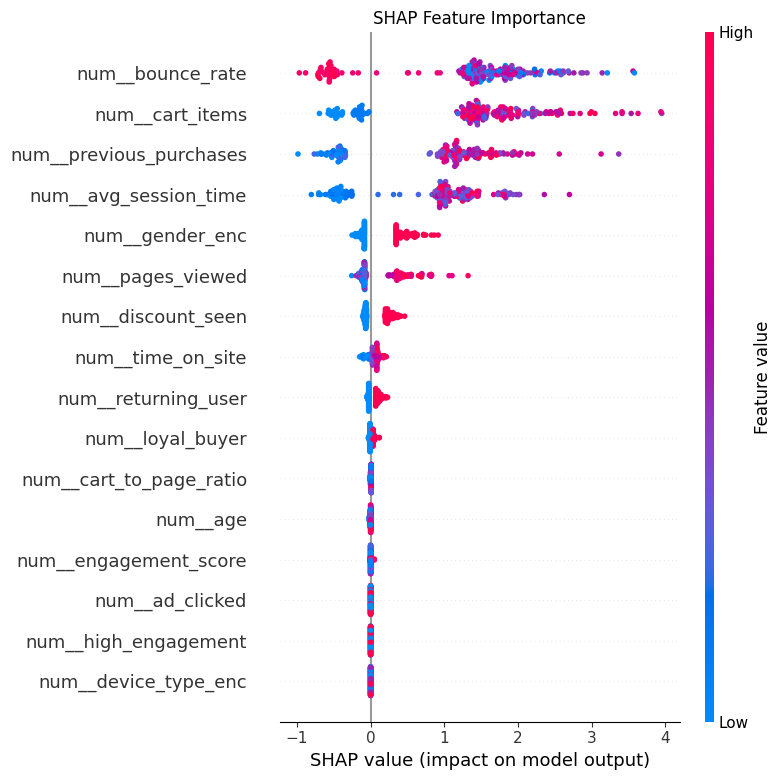

SHAP summary plot saved as 'shap_summary.png'


In [ ]:

if best_model_name in ['Random Forest', 'XGBoost', 'CatBoost', 'Decision Tree', 'Gradient Boosting']:
    print("\n--- SHAP Feature Importance ---")
    X_sample = X_test.sample(min(200, len(X_test)), random_state=SEED)
    X_trans = best_pipeline.named_steps['prep'].transform(X_sample)
    model = best_pipeline.named_steps['clf']
    feature_names = best_pipeline.named_steps['prep'].get_feature_names_out()
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_trans)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]   # for binary classification, take positive class
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_trans, feature_names=feature_names, show=False)
    plt.title("SHAP Feature Importance")
    plt.tight_layout()
    plt.savefig("shap_summary.png")
    plt.show()
    print("SHAP summary plot saved as 'shap_summary.png'")
else:
    print("SHAP analysis skipped – best model is not tree‑based.")


In [ ]:

from sklearn.calibration import calibration_curve



--- Threshold Tuning (maximising F1) ---
Optimal threshold = 0.021 (F1 = 0.999)
Precision = 0.999, Recall = 1.000

--- Model Calibration ---


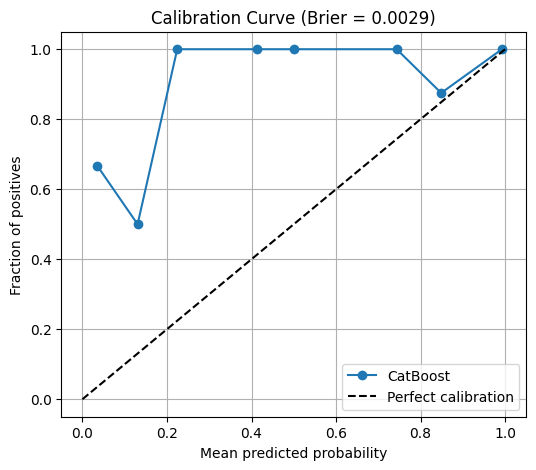


Classification Report (optimal threshold):
              precision    recall  f1-score   support

           0      1.000     0.250     0.400         4
           1      0.999     1.000     0.999      2348

    accuracy                          0.999      2352
   macro avg      0.999     0.625     0.700      2352
weighted avg      0.999     0.999     0.998      2352



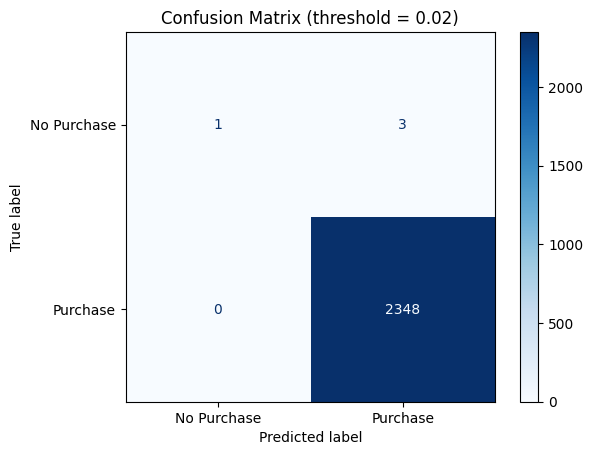


Advanced modeling completed. Outputs saved as PNG files.


In [ ]:
print("\n--- Threshold Tuning (maximising F1) ---")
y_proba = best_pipeline.predict_proba(X_test)[:, 1]
prec, rec, thresholds = precision_recall_curve(y_test, y_proba)
f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-8)
opt_idx = np.argmax(f1)
opt_thresh = thresholds[opt_idx] if opt_idx < len(thresholds) else 0.5
print(f"Optimal threshold = {opt_thresh:.3f} (F1 = {f1[opt_idx]:.3f})")
print(f"Precision = {prec[opt_idx]:.3f}, Recall = {rec[opt_idx]:.3f}")

# Calibration curve
print("\n--- Model Calibration ---")
brier = brier_score_loss(y_test, y_proba)
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label=best_model_name)
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title(f'Calibration Curve (Brier = {brier:.4f})')
plt.legend()
plt.grid()
plt.savefig("calibration_curve.png")
plt.show()

# Final classification report with optimal threshold
y_pred_opt = (y_proba >= opt_thresh).astype(int)
print("\nClassification Report (optimal threshold):")
print(classification_report(y_test, y_pred_opt, digits=3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Purchase', 'Purchase'])
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (threshold = {opt_thresh:.2f})")
plt.savefig("confusion_matrix_optimal.png")
plt.show()

print("\nAdvanced modeling completed. Outputs saved as PNG files.")